# Seasonal Agriculture Performance Analysis

### Major Project

This project analyzes agricultural data from different seasons,
regions and farming conditions.

The analysis focuses on crop performance, environmental conditions,
resource usage, irrigation, economic performance and seasonal patterns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv("/content/seasonal_agriculture_performance_dataset (2).csv")



In [4]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [5]:
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


DATASET SIZE

In [6]:
print("Number of records:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of records: 4000
Number of columns: 28


DATA TYPES

In [7]:
print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nNumber of Numeric Columns:",
      df.select_dtypes(include=np.number).shape[1])

print("Number of Categorical Columns:",
      df.select_dtypes(include="object").shape[1])

Dataset Shape: (4000, 28)

Data Types:
Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                 object
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR       

DUPLICATE RECORDS

In [8]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicate records removed.")
else:
    print("No duplicate records found.")

Number of duplicate records: 0
No duplicate records found.


2) NUMBER OF STATES

In [9]:
print("Number of states:", df["State"].nunique())

Number of states: 8


3) NUMBER OF DISTRICTS

In [10]:
print("Number of districts:", df["District"].nunique())

Number of districts: 10


4) NUMBER OF CROPS

In [11]:
print("Number of crops:", df["Crop"].nunique())

Number of crops: 8


5) RECORDS BY SEASON

In [12]:
df["Season"].value_counts()

,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


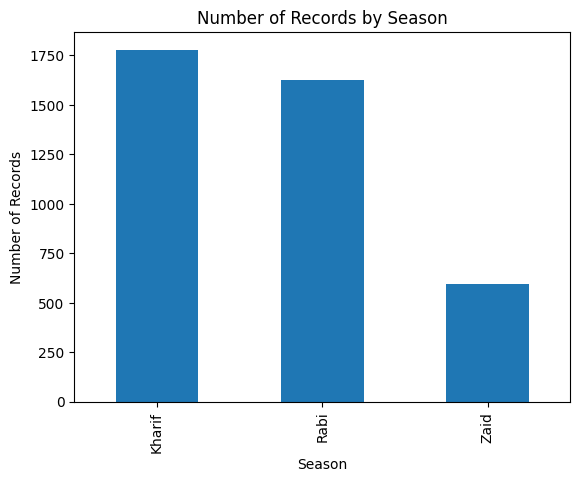

In [13]:
df["Season"].value_counts().plot(kind="bar")

plt.title("Number of Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.show()

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

CHECKING MISSING VALUES

In [15]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [16]:
df["Rainfall_mm"] = df["Rainfall_mm"].fillna(df["Rainfall_mm"].median())

df["Soil_Moisture_pct"] = df["Soil_Moisture_pct"].fillna(df["Soil_Moisture_pct"].median())

df["Yield_Tonnes_Ha"] = df["Yield_Tonnes_Ha"].fillna(df["Yield_Tonnes_Ha"].median())

print("Missing values filled")

Missing values filled


In [17]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [18]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,600.922825,26.81890,63.210500,7.323050,6.701010,26.507150,120.250825,57.781850,104.760050,...,0.826138,5.242350,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,287.193381,3.81818,11.960834,1.121186,0.641461,6.678837,31.216452,17.015074,27.742681,...,0.101747,13.311549,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,371.575000,23.90000,54.775000,6.600000,6.260000,21.800000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,831.975000,29.60000,71.900000,8.100000,7.140000,31.200000,141.225000,69.400000,123.600000,...,0.910000,2.830000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


OUTLIERS

Lower limit: -1.6199999999999999
Upper limit: 5.5
Number of yield outliers: 302


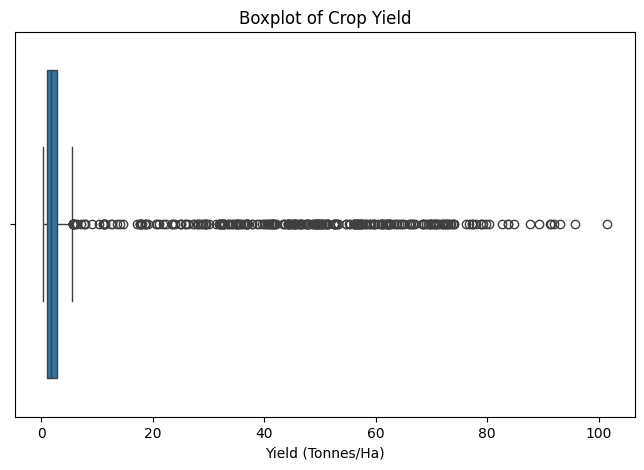

In [20]:
# OUTLIER ANALYSIS - YIELD

Q1 = df["Yield_Tonnes_Ha"].quantile(0.25)
Q3 = df["Yield_Tonnes_Ha"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

yield_outliers = df[
    (df["Yield_Tonnes_Ha"] < lower_limit) |
    (df["Yield_Tonnes_Ha"] > upper_limit)
]

print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)
print("Number of yield outliers:", len(yield_outliers))

plt.figure(figsize=(8, 5))

sns.boxplot(x=df["Yield_Tonnes_Ha"])

plt.title("Boxplot of Crop Yield")
plt.xlabel("Yield (Tonnes/Ha)")
plt.show()

PROFIT OUTLIERS

Number of profit outliers: 404


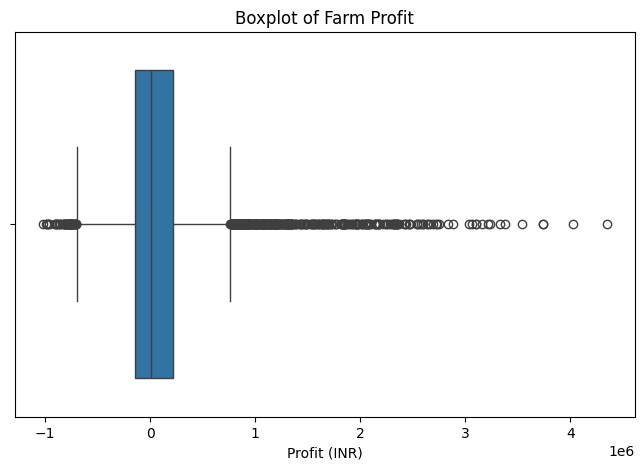

In [21]:
Q1_profit = df["Profit_INR"].quantile(0.25)
Q3_profit = df["Profit_INR"].quantile(0.75)

IQR_profit = Q3_profit - Q1_profit

lower_profit = Q1_profit - 1.5 * IQR_profit
upper_profit = Q3_profit + 1.5 * IQR_profit

profit_outliers = df[
    (df["Profit_INR"] < lower_profit) |
    (df["Profit_INR"] > upper_profit)
]

print("Number of profit outliers:", len(profit_outliers))

plt.figure(figsize=(8, 5))

sns.boxplot(x=df["Profit_INR"])

plt.title("Boxplot of Farm Profit")
plt.xlabel("Profit (INR)")
plt.show()

WATER USAGE OUTLIERS

Number of water usage outliers: 276


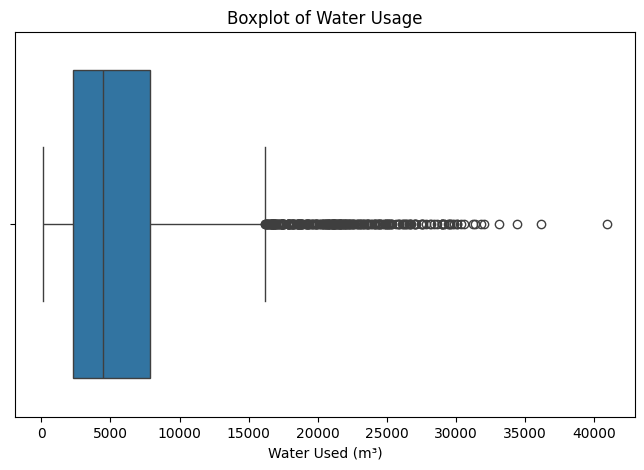

In [22]:
Q1_water = df["Water_Used_m3"].quantile(0.25)
Q3_water = df["Water_Used_m3"].quantile(0.75)

IQR_water = Q3_water - Q1_water

lower_water = Q1_water - 1.5 * IQR_water
upper_water = Q3_water + 1.5 * IQR_water

water_outliers = df[
    (df["Water_Used_m3"] < lower_water) |
    (df["Water_Used_m3"] > upper_water)
]

print("Number of water usage outliers:", len(water_outliers))

plt.figure(figsize=(8, 5))

sns.boxplot(x=df["Water_Used_m3"])

plt.title("Boxplot of Water Usage")
plt.xlabel("Water Used (m³)")
plt.show()

UNIVARIATE ANALYSIS

Number of records by season:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


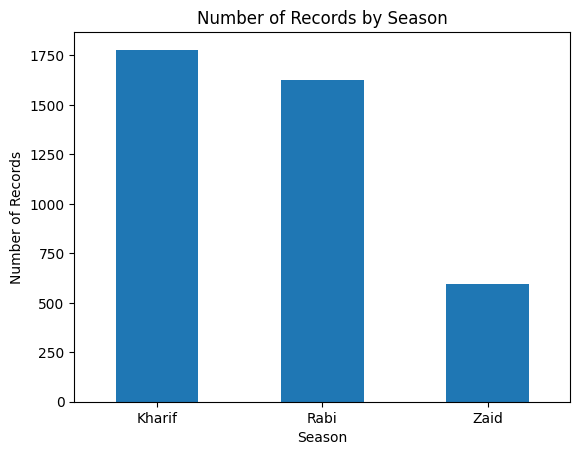

In [23]:
# UNIVARIATE ANALYSIS - SEASON

season_count = df["Season"].value_counts()

print("Number of records by season:")
print(season_count)

season_count.plot(kind="bar")

plt.title("Number of Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.show()

Number of records by crop:
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64


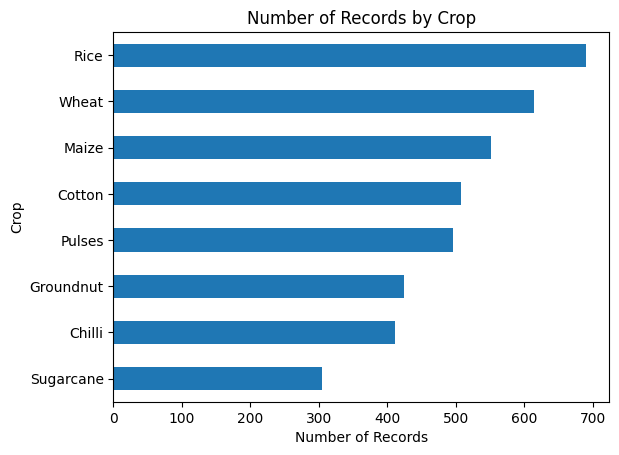

In [24]:
# UNIVARIATE ANALYSIS - CROP

crop_count = df["Crop"].value_counts()

print("Number of records by crop:")
print(crop_count)

crop_count.sort_values().plot(kind="barh")

plt.title("Number of Records by Crop")
plt.xlabel("Number of Records")
plt.ylabel("Crop")
plt.show()

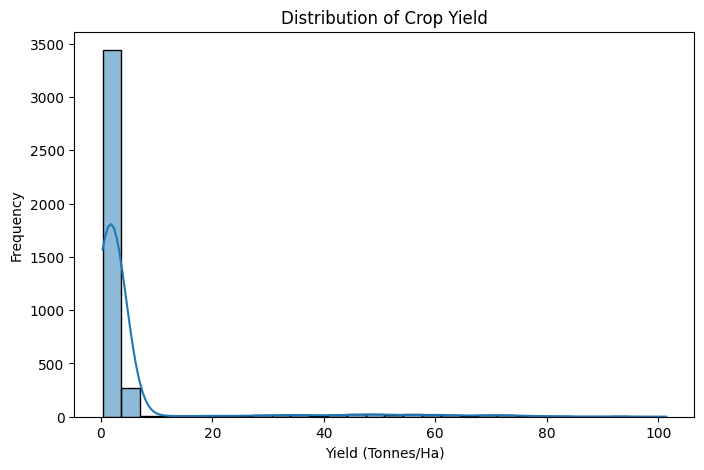

In [25]:
# UNIVARIATE ANALYSIS - YIELD

plt.figure(figsize=(8, 5))

sns.histplot(df["Yield_Tonnes_Ha"], bins=30, kde=True)

plt.title("Distribution of Crop Yield")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Frequency")
plt.show()

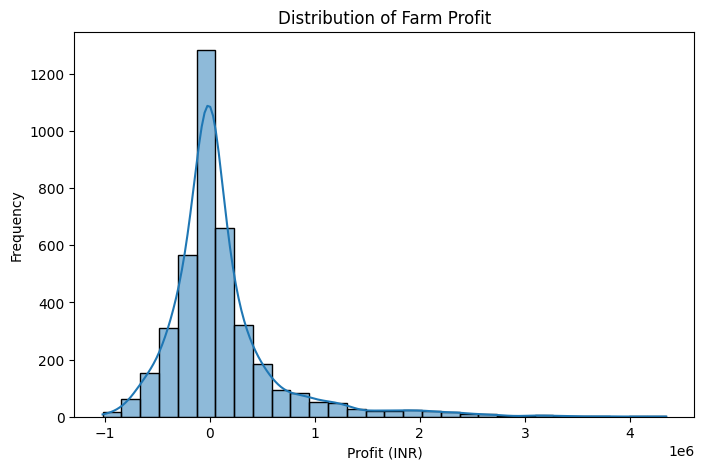

In [26]:
# UNIVARIATE ANALYSIS - PROFIT

plt.figure(figsize=(8, 5))

sns.histplot(df["Profit_INR"], bins=30, kde=True)

plt.title("Distribution of Farm Profit")
plt.xlabel("Profit (INR)")
plt.ylabel("Frequency")
plt.show()

BIVARIATE ANALYSIS

Season
Kharif    5.628612
Rabi      5.039435
Zaid      4.641313
Name: Yield_Tonnes_Ha, dtype: float64


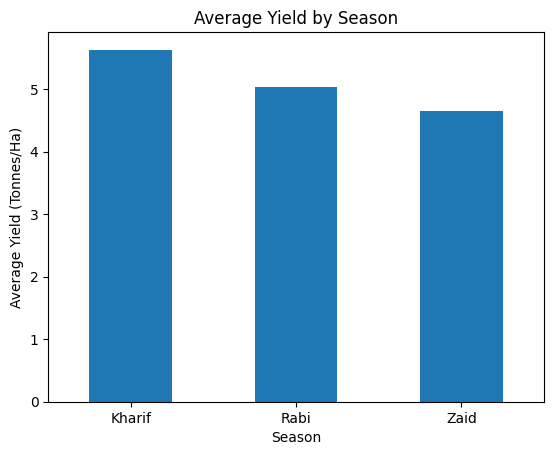

In [27]:
# BIVARIATE ANALYSIS - SEASON VS YIELD

season_yield = df.groupby("Season")["Yield_Tonnes_Ha"].mean()

print(season_yield)

season_yield.plot(kind="bar")

plt.title("Average Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=0)
plt.show()

Correlation between rainfall and yield: 0.031


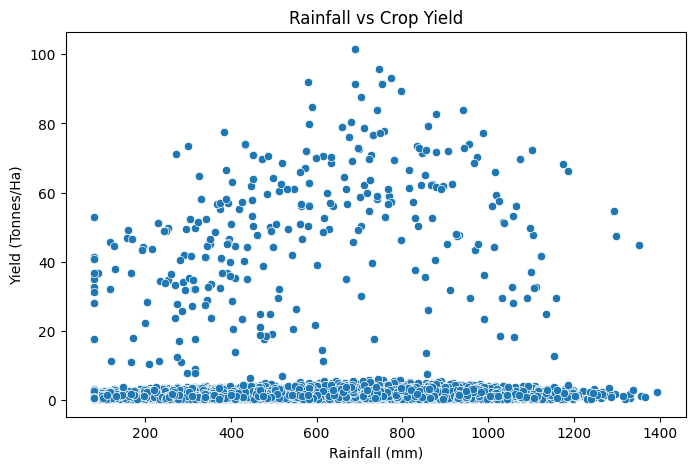

In [28]:
# BIVARIATE ANALYSIS - RAINFALL VS YIELD

rainfall_yield_corr = df["Rainfall_mm"].corr(
    df["Yield_Tonnes_Ha"]
)

print("Correlation between rainfall and yield:",
      round(rainfall_yield_corr, 3))

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha"
)

plt.title("Rainfall vs Crop Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

Correlation between temperature and yield: 0.01


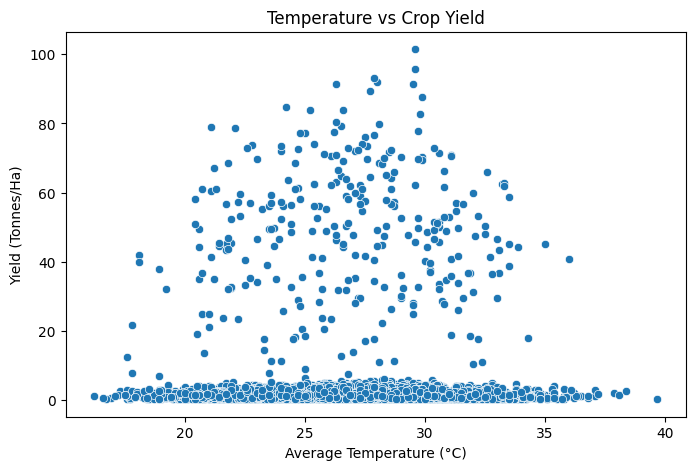

In [29]:
# BIVARIATE ANALYSIS - TEMPERATURE VS YIELD

temperature_yield_corr = df["Avg_Temperature_C"].corr(
    df["Yield_Tonnes_Ha"]
)

print("Correlation between temperature and yield:",
      round(temperature_yield_corr, 3))

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Avg_Temperature_C",
    y="Yield_Tonnes_Ha"
)

plt.title("Temperature vs Crop Yield")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

Correlation between fertilizer and yield: 0.0


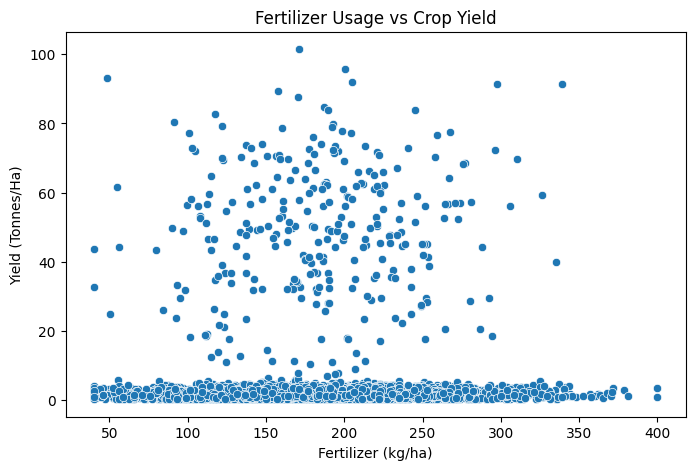

In [30]:
# BIVARIATE ANALYSIS - FERTILIZER VS YIELD

fertilizer_yield_corr = df["Fertilizer_kg_ha"].corr(
    df["Yield_Tonnes_Ha"]
)

print("Correlation between fertilizer and yield:",
      round(fertilizer_yield_corr, 3))

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Fertilizer_kg_ha",
    y="Yield_Tonnes_Ha"
)

plt.title("Fertilizer Usage vs Crop Yield")
plt.xlabel("Fertilizer (kg/ha)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

MULTIVARIATE ANALYSIS

Season        Kharif       Rabi       Zaid
Crop                                      
Chilli      1.731459   1.465031   1.195312
Cotton      1.374512   1.198358   0.960217
Groundnut   1.484974   1.233164   1.037778
Maize       2.966410   2.603648   2.290952
Pulses      1.036063   0.875962   0.669677
Rice        2.698376   2.322847   1.900490
Sugarcane  53.459120  43.286124  38.423922
Wheat       2.253664   2.057468   1.748588


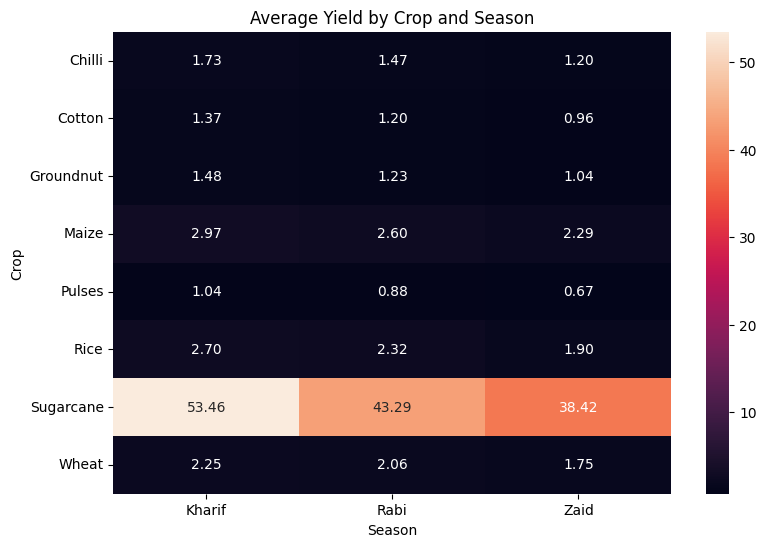

In [31]:
# MULTIVARIATE ANALYSIS - CROP, SEASON AND YIELD

crop_season_yield = pd.pivot_table(
    df,
    values="Yield_Tonnes_Ha",
    index="Crop",
    columns="Season",
    aggfunc="mean"
)

print(crop_season_yield)

plt.figure(figsize=(9, 6))

sns.heatmap(
    crop_season_yield,
    annot=True,
    fmt=".2f"
)

plt.title("Average Yield by Crop and Season")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.show()

Season            Kharif      Rabi      Zaid
State                                       
Andhra Pradesh  5.676958  3.470931  4.448000
Gujarat         6.338416  5.441700  4.066716
Karnataka       6.455024  4.567864  6.623243
Madhya Pradesh  5.985265  3.760385  5.478889
Maharashtra     5.430315  5.501927  2.277778
Punjab          4.100633  8.609355  5.909610
Tamil Nadu      5.520534  4.501394  4.097746
Telangana       5.552436  4.784569  4.248471


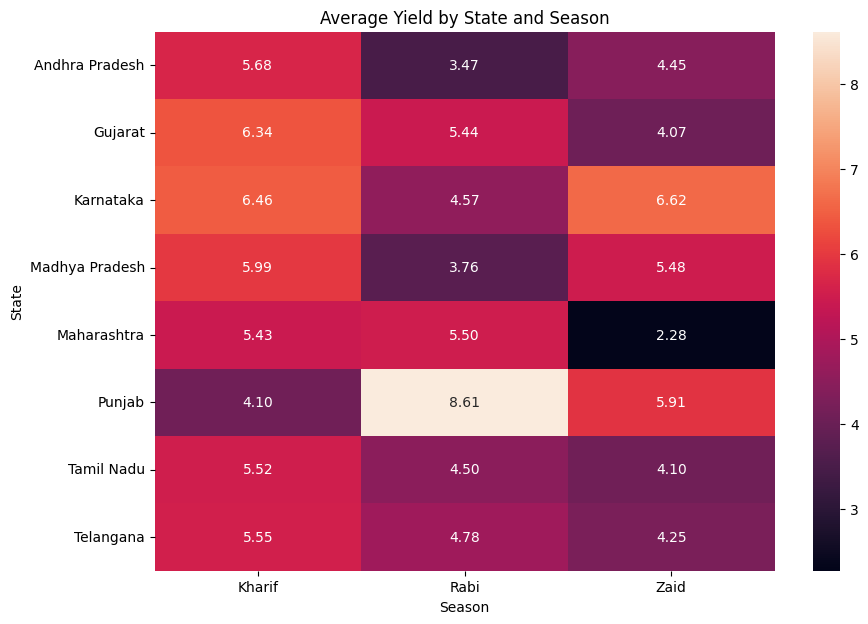

In [32]:
# MULTIVARIATE ANALYSIS - STATE, SEASON AND YIELD

state_season_yield = pd.pivot_table(
    df,
    values="Yield_Tonnes_Ha",
    index="State",
    columns="Season",
    aggfunc="mean"
)

print(state_season_yield)

plt.figure(figsize=(10, 7))

sns.heatmap(
    state_season_yield,
    annot=True,
    fmt=".2f"
)

plt.title("Average Yield by State and Season")
plt.xlabel("Season")
plt.ylabel("State")
plt.show()

How does average yield vary across seasons?

In [19]:
season_yield = df.groupby("Season")["Yield_Tonnes_Ha"].mean()

season_yield

,Yield_Tonnes_Ha
Season,
Kharif,5.628612
Rabi,5.039435
Zaid,4.641313


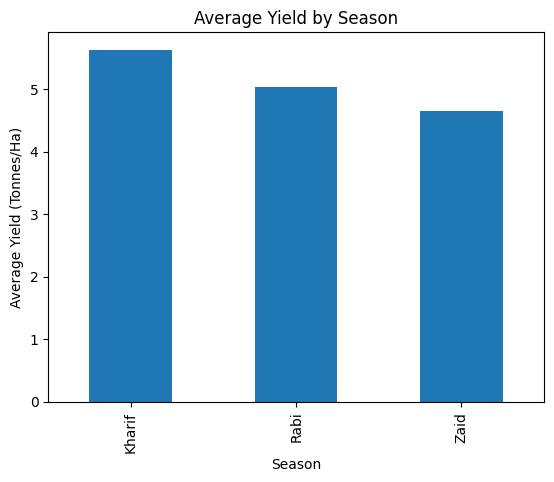

In [33]:
season_yield.plot(kind="bar")

plt.title("Average Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.show()

How does average production vary across seasons?

In [34]:
season_production = df.groupby("Season")["Production_Tonnes"].mean()

season_production

,Production_Tonnes
Season,
Kharif,46.311192
Rabi,41.486712
Zaid,38.886111


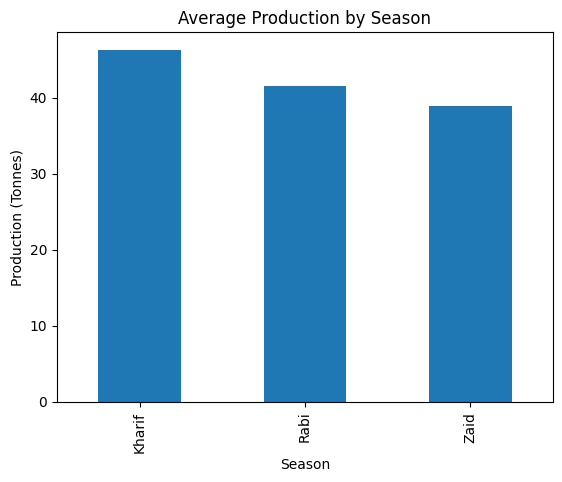

In [35]:
season_production.plot(kind="bar")

plt.title("Average Production by Season")
plt.xlabel("Season")
plt.ylabel("Production (Tonnes)")
plt.show()

How does average revenue vary across seasons?

In [36]:
season_revenue = df.groupby("Season")["Revenue_INR"].mean()

season_revenue

,Revenue_INR
Season,
Kharif,710719.055649
Rabi,601526.048556
Zaid,519171.904040


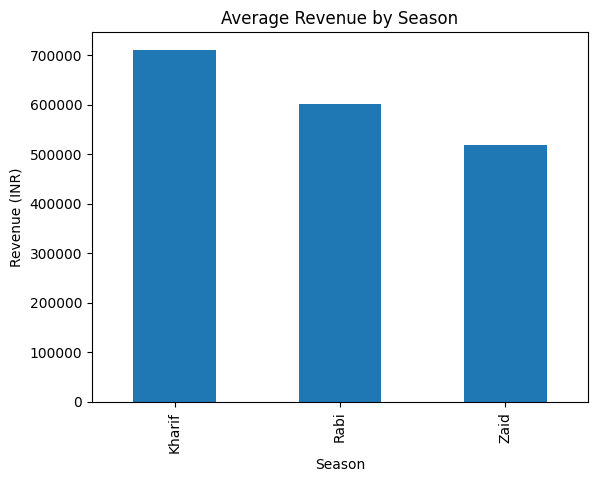

In [37]:
season_revenue.plot(kind="bar")

plt.title("Average Revenue by Season")
plt.xlabel("Season")
plt.ylabel("Revenue (INR)")
plt.show()

How does average profit vary across seasons?

In [38]:
season_profit = df.groupby("Season")["Profit_INR"].mean()

season_profit

,Profit_INR
Season,
Kharif,178914.647555
Rabi,87689.470191
Zaid,-24804.824916


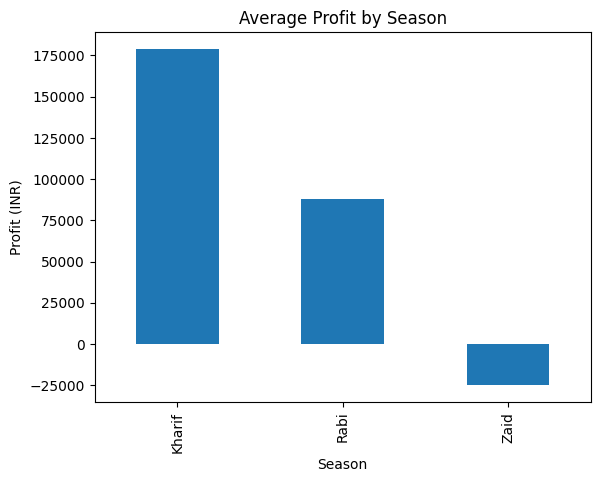

In [39]:
season_profit.plot(kind="bar")

plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.show()

Which season performs best overall?

In [41]:
season_result = df.groupby("Season")[
    [
        "Yield_Tonnes_Ha",
        "Production_Tonnes",
        "Revenue_INR",
        "Profit_INR"
    ]
].mean()

season_result

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR
Season,,,,
Kharif,5.628612,46.311192,710719.055649,178914.647555
Rabi,5.039435,41.486712,601526.048556,87689.470191
Zaid,4.641313,38.886111,519171.904040,-24804.824916


In [ ]:
print("Highest yield:", season_result["Yield_Tonnes_Ha"].idxmax())
print("Highest production:", season_result["Production_Tonnes"].idxmax())
print("Highest revenue:", season_result["Revenue_INR"].idxmax())
print("Highest profit:", season_result["Profit_INR"].idxmax())

CROP ANALYSIS

Which crop has the highest average yield?

In [42]:
crop_yield = df.groupby("Crop")["Yield_Tonnes_Ha"].mean()

crop_yield.sort_values(ascending=False)

,Yield_Tonnes_Ha
Crop,
Sugarcane,46.642361
Maize,2.710036
Rice,2.431304
Wheat,2.108013
Chilli,1.542767
Groundnut,1.322901
Cotton,1.229783
Pulses,0.921512


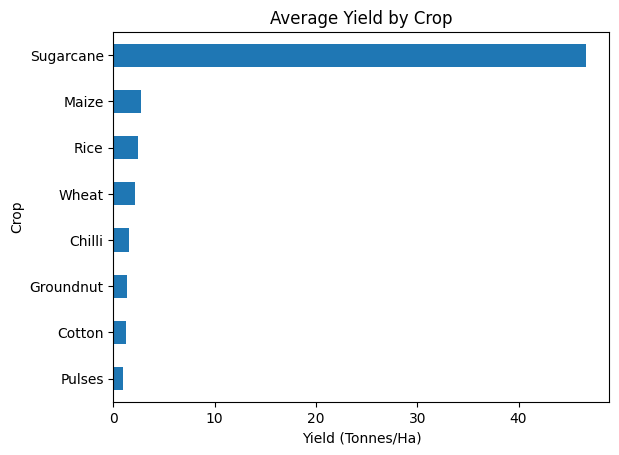

In [43]:
crop_yield.sort_values().plot(kind="barh")

plt.title("Average Yield by Crop")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Crop")
plt.show()

Which crop has the highest average production?

In [44]:
crop_production = df.groupby("Crop")["Production_Tonnes"].mean()

crop_production.sort_values(ascending=False)

,Production_Tonnes
Crop,
Sugarcane,392.413016
Maize,21.781125
Rice,19.288623
Wheat,16.853909
Chilli,12.382888
Groundnut,9.655825
Cotton,9.395866
Pulses,7.401411


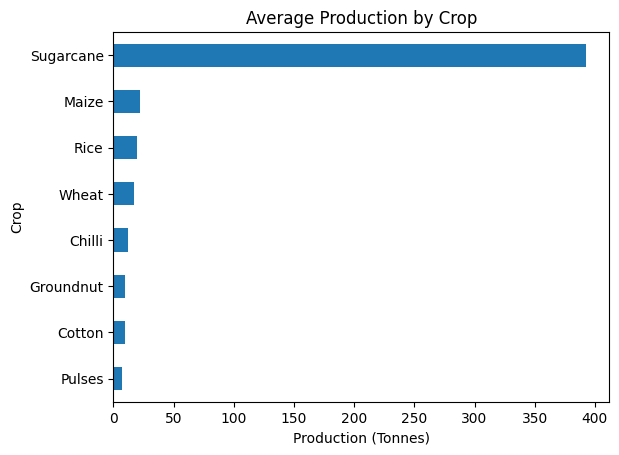

In [45]:
crop_production.sort_values().plot(kind="barh")

plt.title("Average Production by Crop")
plt.xlabel("Production (Tonnes)")
plt.ylabel("Crop")
plt.show()

Which crop has the highest average profit?

In [46]:
crop_profit = df.groupby("Crop")["Profit_INR"].mean()

crop_profit.sort_values(ascending=False)

,Profit_INR
Crop,
Sugarcane,817187.986885
Chilli,750878.342233
Cotton,124546.915354
Groundnut,44858.120283
Pulses,-4238.052419
Maize,-83978.326679
Rice,-102213.504348
Wheat,-123398.337134


Which crops are most commonly grown?

In [47]:
crop_count = df["Crop"].value_counts()

crop_count

,count
Crop,
Rice,690
Wheat,614
Maize,551
Cotton,508
Pulses,496
Groundnut,424
Chilli,412
Sugarcane,305


Which crop performs best in each season?

In [48]:
crop_season_yield = df.groupby(
    ["Season", "Crop"]
)["Yield_Tonnes_Ha"].mean()

crop_season_yield

Season  Crop     
Kharif  Chilli        1.731459
        Cotton        1.374512
        Groundnut     1.484974
        Maize         2.966410
        Pulses        1.036063
        Rice          2.698376
        Sugarcane    53.459120
        Wheat         2.253664
Rabi    Chilli        1.465031
        Cotton        1.198358
        Groundnut     1.233164
        Maize         2.603648
        Pulses        0.875962
        Rice          2.322847
        Sugarcane    43.286124
        Wheat         2.057468
Zaid    Chilli        1.195312
        Cotton        0.960217
        Groundnut     1.037778
        Maize         2.290952
        Pulses        0.669677
        Rice          1.900490
        Sugarcane    38.423922
        Wheat         1.748588
Name: Yield_Tonnes_Ha, dtype: float64

In [ ]:
for season in df["Season"].unique():
    data = crop_season_yield[season]
    print(season, ":", data.idxmax(), "-", round(data.max(), 2))

Does crop performance change across seasons?

In [49]:
crop_season = df.pivot_table(
    values="Yield_Tonnes_Ha",
    index="Crop",
    columns="Season",
    aggfunc="mean"
)

crop_season

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.731459,1.465031,1.195312
Cotton,1.374512,1.198358,0.960217
Groundnut,1.484974,1.233164,1.037778
Maize,2.966410,2.603648,2.290952
Pulses,1.036063,0.875962,0.669677
Rice,2.698376,2.322847,1.900490
Sugarcane,53.459120,43.286124,38.423922
Wheat,2.253664,2.057468,1.748588


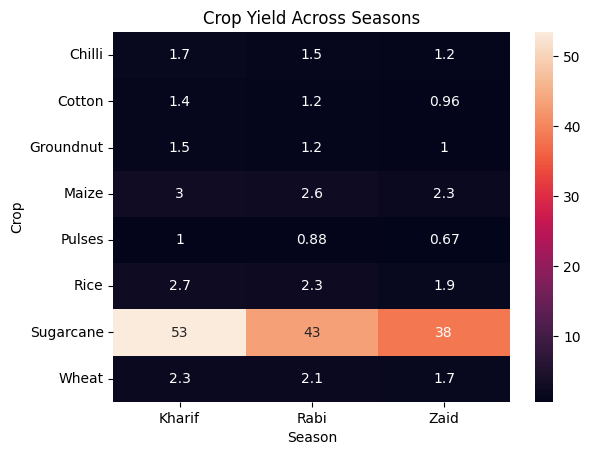

In [50]:
sns.heatmap(crop_season, annot=True)

plt.title("Crop Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.show()

How does rainfall vary across seasons?

In [51]:
rainfall = df.groupby("Season")["Rainfall_mm"].mean()

rainfall

,Rainfall_mm
Season,
Kharif,849.199663
Rabi,437.615366
Zaid,304.654714


How does temperature vary across seasons?

In [52]:
temperature = df.groupby("Season")["Avg_Temperature_C"].mean()

temperature

,Avg_Temperature_C
Season,
Kharif,28.454019
Rabi,23.489183
Zaid,31.042088


How does humidity vary across seasons?

In [53]:
humidity = df.groupby("Season")["Humidity_pct"].mean()

humidity

,Humidity_pct
Season,
Kharif,71.812591
Rabi,57.893178
Zaid,52.012121


How does soil moisture vary across seasons?

In [54]:
soil_moisture = df.groupby("Season")["Soil_Moisture_pct"].mean()

soil_moisture

,Soil_Moisture_pct
Season,
Kharif,31.149859
Rabi,24.069392
Zaid,19.279630


Is rainfall related to crop yield?

In [55]:
print(
    "Correlation:",
    df["Rainfall_mm"].corr(df["Yield_Tonnes_Ha"])
)

Correlation: 0.030950993551650874


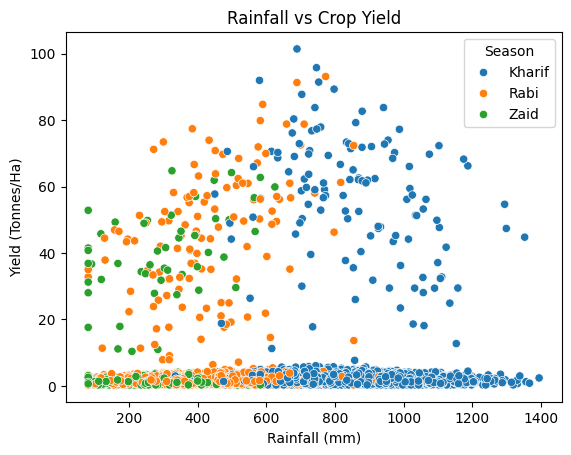

In [56]:
sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Rainfall vs Crop Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

Is temperature related to crop yield?

In [57]:
print(
    "Correlation:",
    df["Avg_Temperature_C"].corr(df["Yield_Tonnes_Ha"])
)

Correlation: 0.009996320546703593


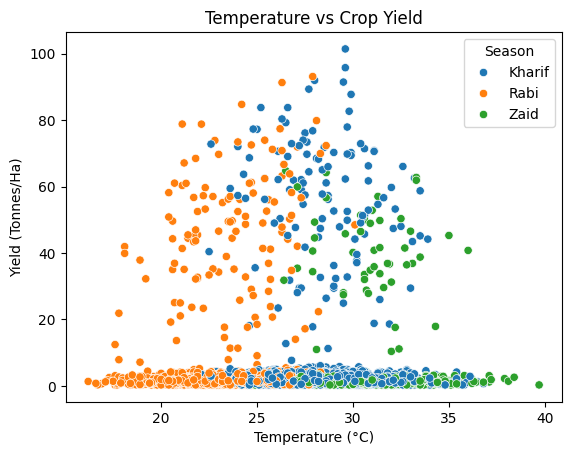

In [58]:
sns.scatterplot(
    data=df,
    x="Avg_Temperature_C",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Temperature vs Crop Yield")
plt.xlabel("Temperature (°C)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

How does fertilizer usage vary across seasons?

In [59]:
fertilizer = df.groupby("Season")["Fertilizer_kg_ha"].mean()

fertilizer

,Fertilizer_kg_ha
Season,
Kharif,187.077965
Rabi,185.407068
Zaid,184.638047


How does water usage vary across seasons?

In [60]:
water = df.groupby("Season")["Water_Used_m3"].mean()

water

,Water_Used_m3
Season,
Kharif,6102.201237
Rabi,5846.987093
Zaid,6419.893939


Is fertilizer usage related to yield?

In [61]:
print(
    "Correlation:",
    df["Fertilizer_kg_ha"].corr(df["Yield_Tonnes_Ha"])
)

Correlation: 1.7712703696042472e-05


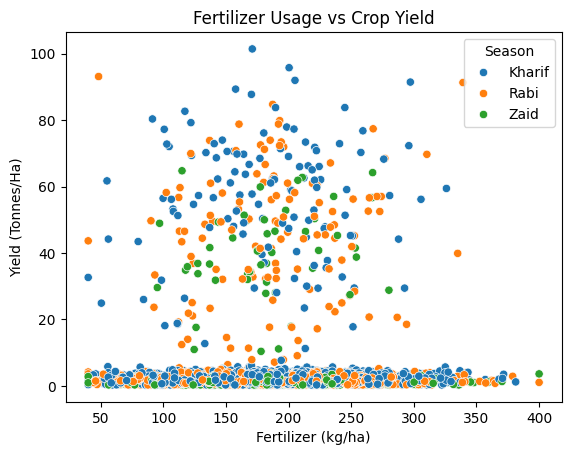

In [62]:
sns.scatterplot(
    data=df,
    x="Fertilizer_kg_ha",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Fertilizer Usage vs Crop Yield")
plt.xlabel("Fertilizer (kg/ha)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

Which irrigation method gives higher average yield?

In [63]:
irrigation_yield = df.groupby(
    "Irrigation_Method"
)["Yield_Tonnes_Ha"].mean()

irrigation_yield.sort_values(ascending=False)

,Yield_Tonnes_Ha
Irrigation_Method,
Drip,6.577989
Sprinkler,5.160627
Flood,4.863977
Rainfed,4.602142


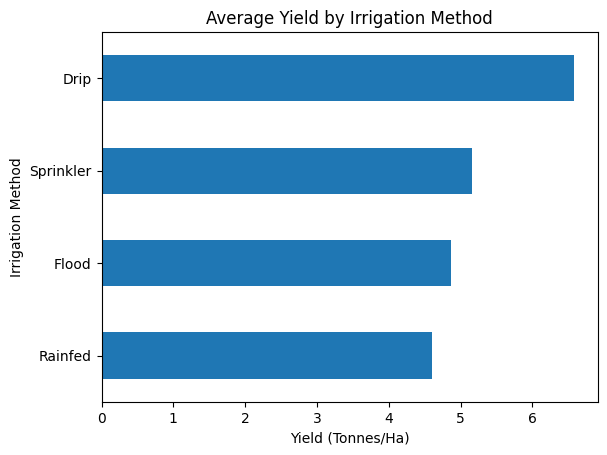

In [64]:
irrigation_yield.sort_values().plot(kind="barh")

plt.title("Average Yield by Irrigation Method")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Irrigation Method")
plt.show()

Which irrigation method has better water efficiency?

In [65]:
water_efficiency = df.groupby(
    "Irrigation_Method"
)["Water_Efficiency_t_per_1000m3"].mean()

water_efficiency.sort_values(ascending=False)

,Water_Efficiency_t_per_1000m3
Irrigation_Method,
Rainfed,7.563784
Drip,6.267129
Sprinkler,4.669805
Flood,3.438853


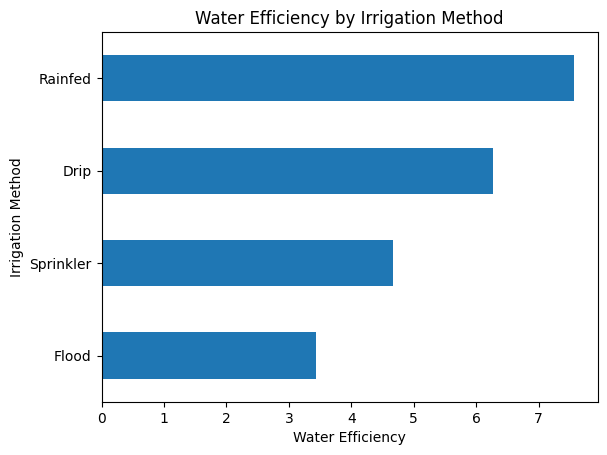

In [66]:
water_efficiency.sort_values().plot(kind="barh")

plt.title("Water Efficiency by Irrigation Method")
plt.xlabel("Water Efficiency")
plt.ylabel("Irrigation Method")
plt.show()

ECONOMIC ANALYSIS

Which season has the highest market price?

In [67]:
market_price = df.groupby(
    "Season"
)["Market_Price_INR_Tonne"].mean()

market_price.sort_values(ascending=False)

,Market_Price_INR_Tonne
Season,
Kharif,44850.906127
Rabi,44747.974800
Zaid,44212.033670


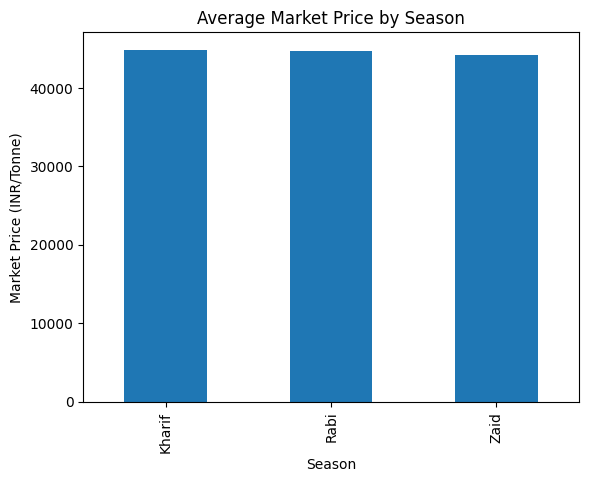

In [68]:
market_price.plot(kind="bar")

plt.title("Average Market Price by Season")
plt.xlabel("Season")
plt.ylabel("Market Price (INR/Tonne)")
plt.show()

Which state has the highest average yield?

In [69]:
state_yield = df.groupby("State")["Yield_Tonnes_Ha"].mean()

state_yield.sort_values(ascending=False)

,Yield_Tonnes_Ha
State,
Punjab,6.121116
Karnataka,5.685481
Gujarat,5.659016
Telangana,5.044477
Maharashtra,5.017480
Madhya Pradesh,4.989940
Tamil Nadu,4.875175
Andhra Pradesh,4.628771


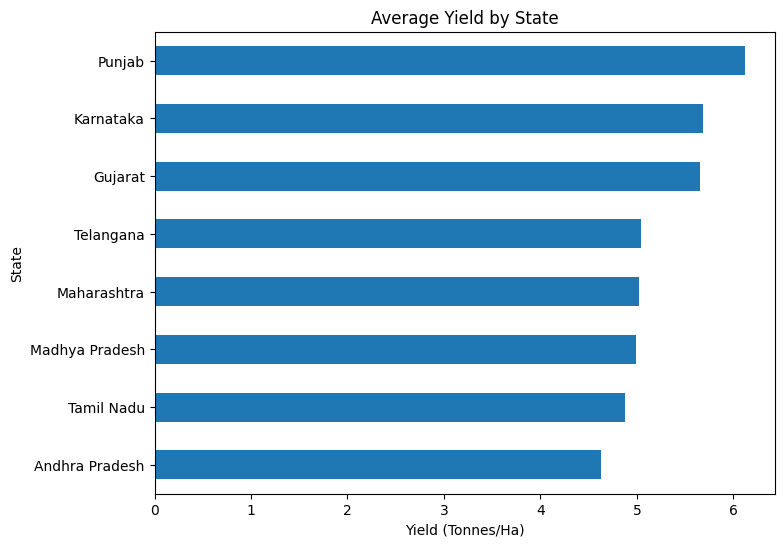

In [70]:
state_yield.sort_values().plot(kind="barh", figsize=(8,6))

plt.title("Average Yield by State")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("State")
plt.show()

Which state has the highest average profit?

In [71]:
state_profit = df.groupby("State")["Profit_INR"].mean()

state_profit.sort_values(ascending=False)

,Profit_INR
State,
Punjab,136025.636364
Maharashtra,135428.855469
Karnataka,119422.335378
Tamil Nadu,117744.748454
Gujarat,117568.235656
Telangana,108829.616279
Madhya Pradesh,86840.756539
Andhra Pradesh,73453.527410


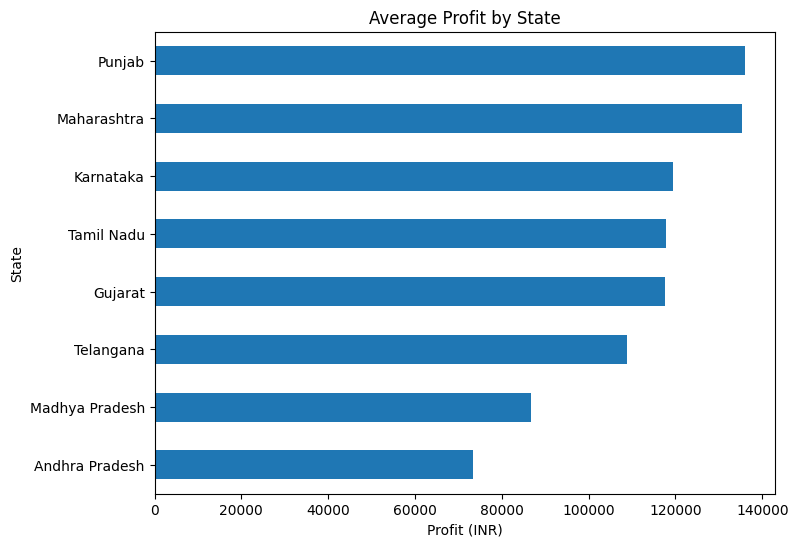

In [72]:
state_profit.sort_values().plot(kind="barh", figsize=(8,6))

plt.title("Average Profit by State")
plt.xlabel("Profit (INR)")
plt.ylabel("State")
plt.show()

Are seasonal yield patterns similar across states?

In [73]:
state_season_yield = df.pivot_table(
    values="Yield_Tonnes_Ha",
    index="State",
    columns="Season",
    aggfunc="mean"
)

state_season_yield

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,5.676958,3.470931,4.448000
Gujarat,6.338416,5.441700,4.066716
Karnataka,6.455024,4.567864,6.623243
Madhya Pradesh,5.985265,3.760385,5.478889
Maharashtra,5.430315,5.501927,2.277778
Punjab,4.100633,8.609355,5.909610
Tamil Nadu,5.520534,4.501394,4.097746
Telangana,5.552436,4.784569,4.248471


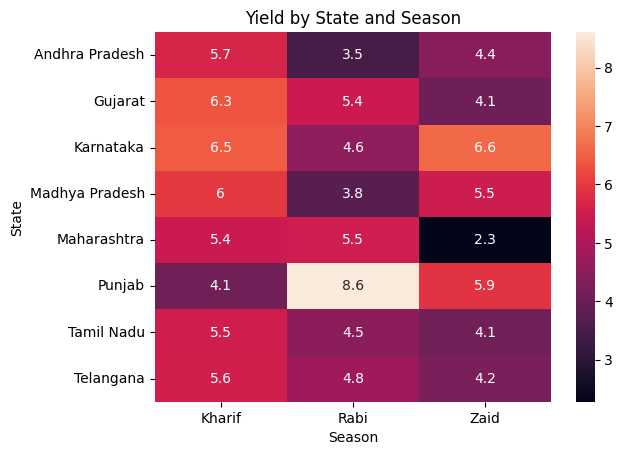

In [74]:
sns.heatmap(state_season_yield, annot=True)

plt.title("Yield by State and Season")
plt.xlabel("Season")
plt.ylabel("State")
plt.show()

RISK ANALYSIS

Which season has the highest disease/pest risk?

In [75]:
risk = df.groupby(
    "Season"
)["Disease_Pest_Risk_pct"].mean()

risk.sort_values(ascending=False)

,Disease_Pest_Risk_pct
Season,
Kharif,54.467903
Rabi,40.482114
Zaid,38.216667


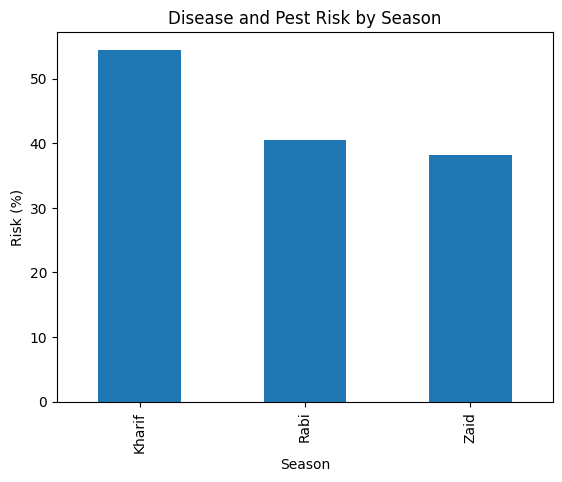

In [76]:
risk.plot(kind="bar")

plt.title("Disease and Pest Risk by Season")
plt.xlabel("Season")
plt.ylabel("Risk (%)")
plt.show()

Which farms have unusually high or low yield?

In [77]:
df.nlargest(10, "Yield_Tonnes_Ha")[
    ["Farm_ID", "State", "Crop", "Season", "Yield_Tonnes_Ha"]
]

,Farm_ID,State,Crop,Season,Yield_Tonnes_Ha
1715,SF11716,Gujarat,Sugarcane,Kharif,101.44
3423,SF13424,Andhra Pradesh,Sugarcane,Kharif,95.79
3525,SF13526,Andhra Pradesh,Sugarcane,Rabi,93.13
1464,SF11465,Gujarat,Sugarcane,Kharif,91.98
3523,SF13524,Karnataka,Sugarcane,Kharif,91.46
2782,SF12783,Gujarat,Sugarcane,Rabi,91.32
644,SF10645,Andhra Pradesh,Sugarcane,Kharif,89.34
2847,SF12848,Telangana,Sugarcane,Kharif,87.76
357,SF10358,Punjab,Sugarcane,Rabi,84.75
1178,SF11179,Karnataka,Sugarcane,Kharif,83.79


In [78]:
df.nsmallest(10, "Yield_Tonnes_Ha")[
    ["Farm_ID", "State", "Crop", "Season", "Yield_Tonnes_Ha"]
]

,Farm_ID,State,Crop,Season,Yield_Tonnes_Ha
1,SF10002,Maharashtra,Maize,Kharif,0.3
12,SF10013,Punjab,Wheat,Rabi,0.3
25,SF10026,Gujarat,Pulses,Kharif,0.3
31,SF10032,Madhya Pradesh,Groundnut,Zaid,0.3
40,SF10041,Karnataka,Pulses,Kharif,0.3
48,SF10049,Andhra Pradesh,Chilli,Zaid,0.3
51,SF10052,Andhra Pradesh,Pulses,Rabi,0.3
104,SF10105,Gujarat,Wheat,Zaid,0.3
107,SF10108,Maharashtra,Groundnut,Kharif,0.3
121,SF10122,Maharashtra,Cotton,Kharif,0.3


STATISTICAL ANALYSIS

Is there a statistically significant difference in yield between seasons?

In [79]:
from scipy.stats import f_oneway

In [80]:
kharif = df[df["Season"] == "Kharif"]["Yield_Tonnes_Ha"]

rabi = df[df["Season"] == "Rabi"]["Yield_Tonnes_Ha"]

zaid = df[df["Season"] == "Zaid"]["Yield_Tonnes_Ha"]

In [81]:
result = f_oneway(kharif, rabi, zaid)

print("F-statistic:", result.statistic)
print("P-value:", result.pvalue)

F-statistic: 1.5438804542488311
P-value: 0.21367813841792296


In [82]:
if result.pvalue < 0.05:
    print("There is a significant difference in yield between the seasons.")
else:
    print("There is no significant difference in yield between the seasons.")

There is no significant difference in yield between the seasons.


CORRELATION ANALYSIS

In [83]:
correlation = df[
    [
        "Rainfall_mm",
        "Avg_Temperature_C",
        "Humidity_pct",
        "Soil_Moisture_pct",
        "Fertilizer_kg_ha",
        "Water_Used_m3",
        "Yield_Tonnes_Ha",
        "Profit_INR"
    ]
].corr()

correlation

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct,Fertilizer_kg_ha,Water_Used_m3,Yield_Tonnes_Ha,Profit_INR
Rainfall_mm,1.000000,0.198492,0.521069,0.508941,0.024602,0.002240,0.030951,0.107648
Avg_Temperature_C,0.198492,1.000000,0.138136,0.084001,0.015861,0.022995,0.009996,0.009043
Humidity_pct,0.521069,0.138136,1.000000,0.446470,0.024623,-0.002086,0.012297,0.063775
Soil_Moisture_pct,0.508941,0.084001,0.446470,1.000000,0.008782,0.003183,0.010999,0.091281
Fertilizer_kg_ha,0.024602,0.015861,0.024623,0.008782,1.000000,0.000895,0.000018,-0.073542
Water_Used_m3,0.002240,0.022995,-0.002086,0.003183,0.000895,1.000000,0.386294,0.190278
Yield_Tonnes_Ha,0.030951,0.009996,0.012297,0.010999,0.000018,0.386294,1.000000,0.488466
Profit_INR,0.107648,0.009043,0.063775,0.091281,-0.073542,0.190278,0.488466,1.000000


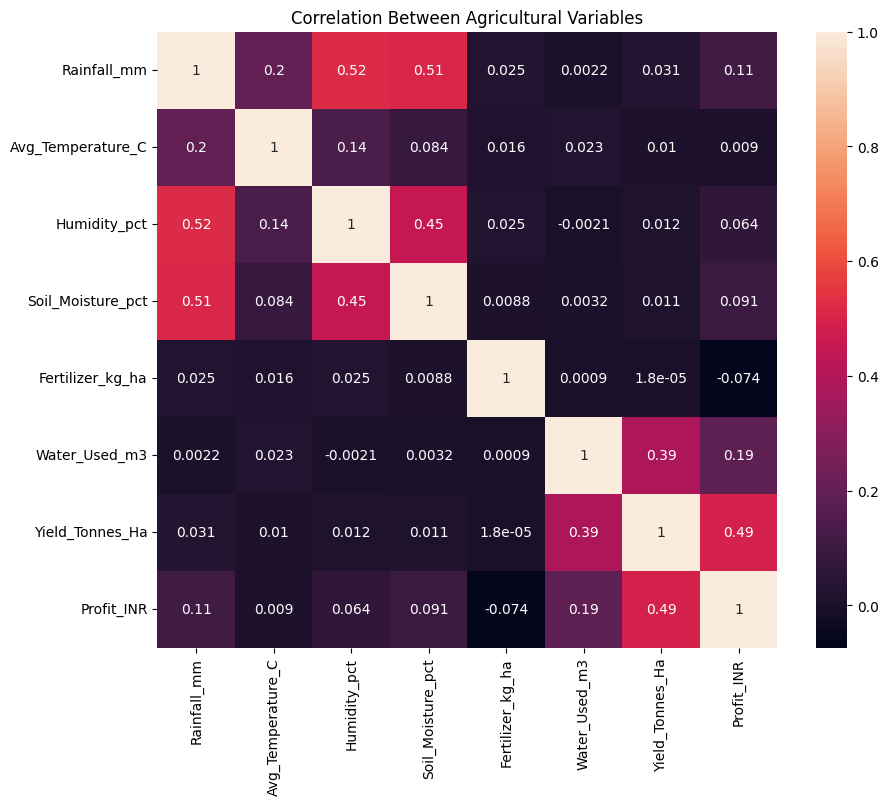

In [85]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation,
    annot=True
)

plt.title("Correlation Between Agricultural Variables")

plt.show()

In [86]:
final_summary = df.groupby("Season").agg({
    "Yield_Tonnes_Ha": "mean",
    "Production_Tonnes": "mean",
    "Revenue_INR": "mean",
    "Profit_INR": "mean",
    "Water_Used_m3": "mean",
    "Water_Efficiency_t_per_1000m3": "mean",
    "Disease_Pest_Risk_pct": "mean"
})

final_summary.round(2)

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,
Kharif,5.63,46.31,710719.06,178914.65,6102.20,5.89,54.47
Rabi,5.04,41.49,601526.05,87689.47,5846.99,5.19,40.48
Zaid,4.64,38.89,519171.90,-24804.82,6419.89,4.41,38.22


In [87]:
print(
    "Best season by yield:",
    final_summary["Yield_Tonnes_Ha"].idxmax()
)

print(
    "Best season by profit:",
    final_summary["Profit_INR"].idxmax()
)

print(
    "Best season by water efficiency:",
    final_summary["Water_Efficiency_t_per_1000m3"].idxmax()
)

print(
    "Highest risk season:",
    final_summary["Disease_Pest_Risk_pct"].idxmax()
)

Best season by yield: Kharif
Best season by profit: Kharif
Best season by water efficiency: Kharif
Highest risk season: Kharif


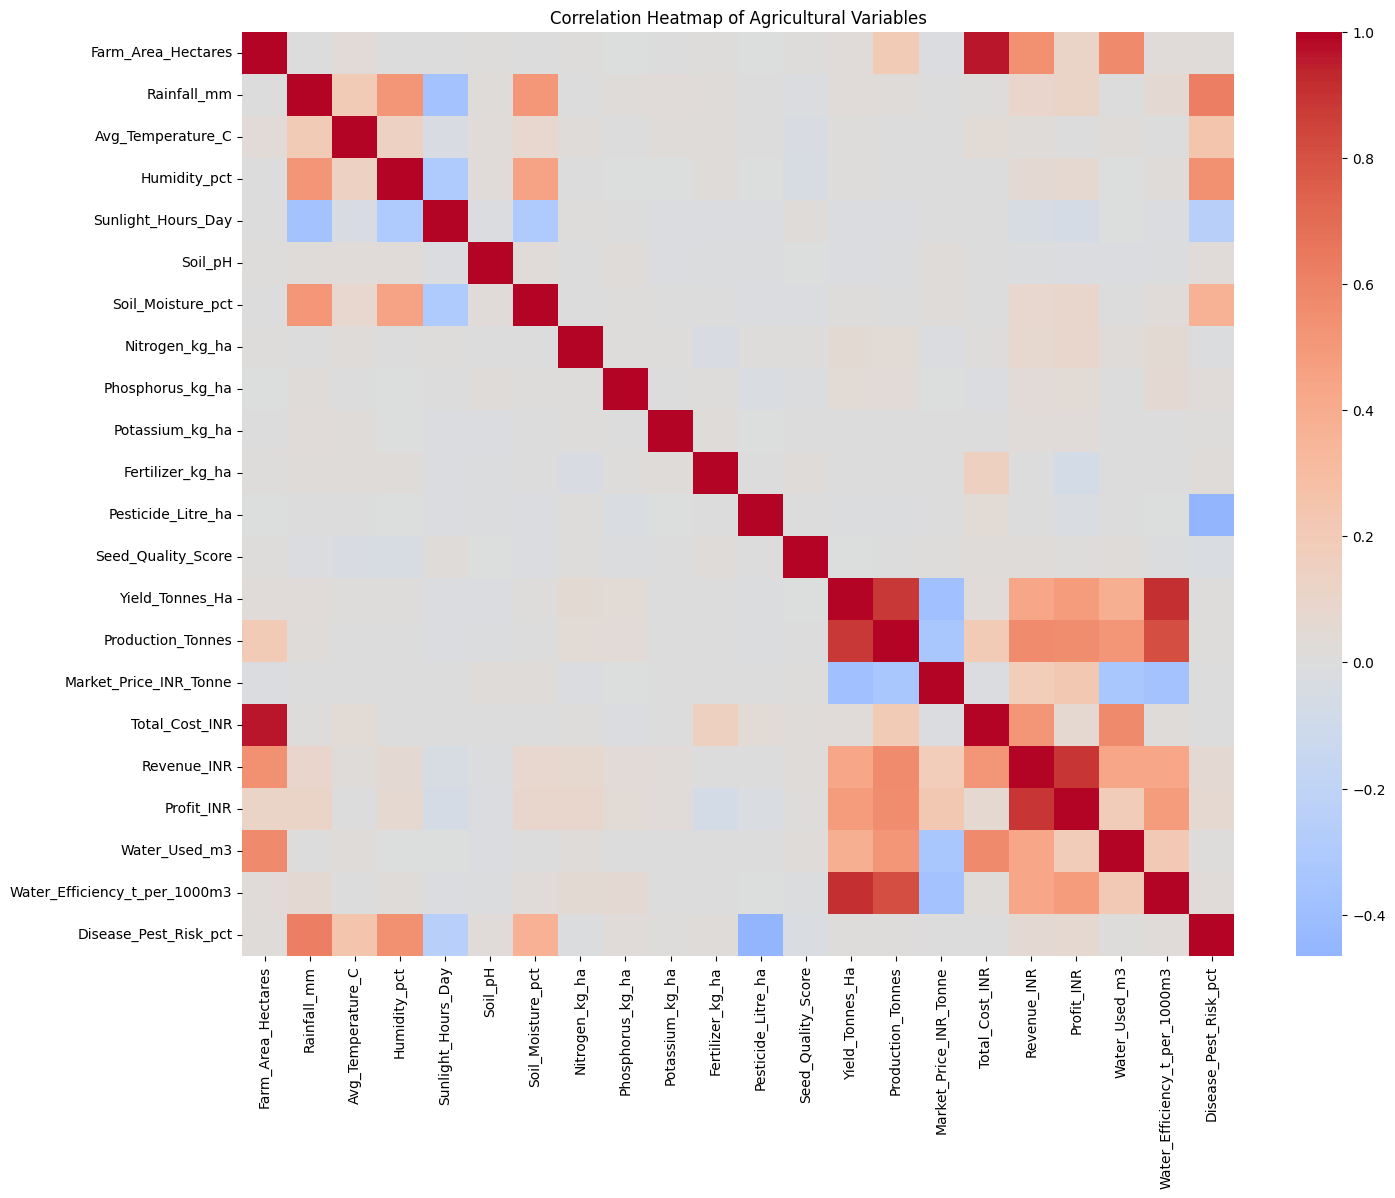

In [88]:
# CORRELATION ANALYSIS

numeric_columns = [
    "Farm_Area_Hectares",
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Seed_Quality_Score",
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Market_Price_INR_Tonne",
    "Total_Cost_INR",
    "Revenue_INR",
    "Profit_INR",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct"
]

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Agricultural Variables")
plt.show()

In [91]:
# BEST PERFORMING CROP IN EACH SEASON

crop_season = df.groupby(
    ["Season", "Crop"]
)["Yield_Tonnes_Ha"].mean().reset_index()

best_crop_each_season = crop_season.loc[
    crop_season.groupby("Season")["Yield_Tonnes_Ha"].idxmax()
]

print("Best performing crop in each season:")
print(best_crop_each_season)

Best performing crop in each season:
    Season       Crop  Yield_Tonnes_Ha
6   Kharif  Sugarcane        53.459120
14    Rabi  Sugarcane        43.286124
22    Zaid  Sugarcane        38.423922


Average profit by state:
State
Punjab            136025.636364
Maharashtra       135428.855469
Karnataka         119422.335378
Tamil Nadu        117744.748454
Gujarat           117568.235656
Telangana         108829.616279
Madhya Pradesh     86840.756539
Andhra Pradesh     73453.527410
Name: Profit_INR, dtype: float64


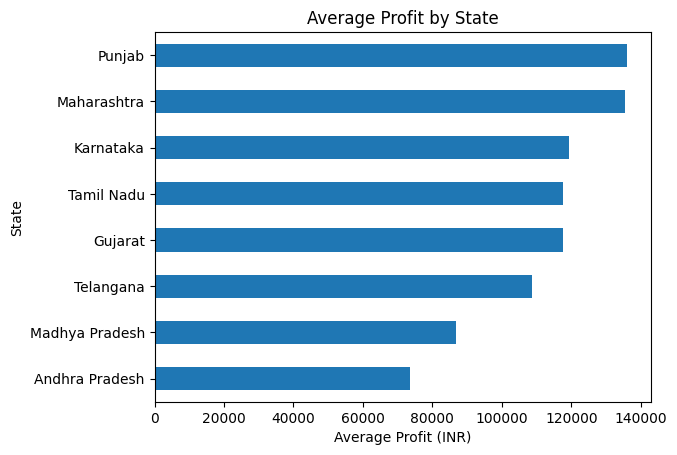

In [92]:
# STATE WITH HIGHEST AVERAGE PROFIT

state_profit = df.groupby("State")["Profit_INR"].mean().sort_values(
    ascending=False
)

print("Average profit by state:")
print(state_profit)

state_profit.sort_values().plot(kind="barh")

plt.title("Average Profit by State")
plt.xlabel("Average Profit (INR)")
plt.ylabel("State")
plt.show()

Average disease/pest risk by season:
Season
Kharif    54.467903
Rabi      40.482114
Zaid      38.216667
Name: Disease_Pest_Risk_pct, dtype: float64


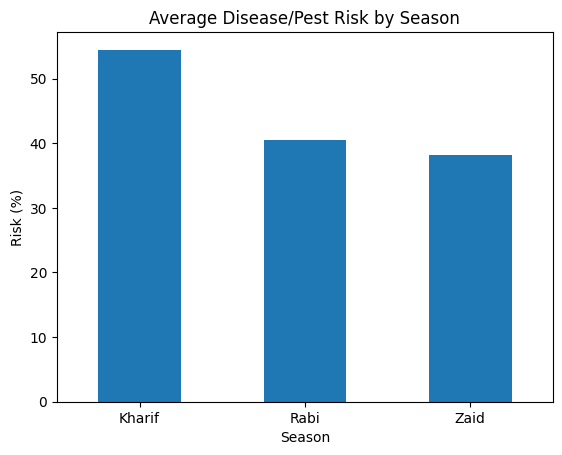

In [93]:
# DISEASE AND PEST RISK BY SEASON

season_risk = df.groupby(
    "Season"
)["Disease_Pest_Risk_pct"].mean().sort_values(
    ascending=False
)

print("Average disease/pest risk by season:")
print(season_risk)

season_risk.plot(kind="bar")

plt.title("Average Disease/Pest Risk by Season")
plt.xlabel("Season")
plt.ylabel("Risk (%)")
plt.xticks(rotation=0)
plt.show()

Average market price by season:
Season
Kharif    44850.906127
Rabi      44747.974800
Zaid      44212.033670
Name: Market_Price_INR_Tonne, dtype: float64


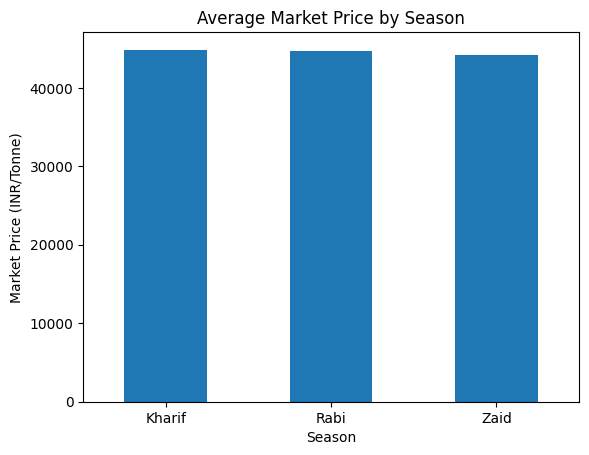

In [94]:
# MARKET PRICE BY SEASON

season_price = df.groupby(
    "Season"
)["Market_Price_INR_Tonne"].mean().sort_values(
    ascending=False
)

print("Average market price by season:")
print(season_price)

season_price.plot(kind="bar")

plt.title("Average Market Price by Season")
plt.xlabel("Season")
plt.ylabel("Market Price (INR/Tonne)")
plt.xticks(rotation=0)
plt.show()

Average yield by state:
State
Punjab            6.121116
Karnataka         5.685481
Gujarat           5.659016
Telangana         5.044477
Maharashtra       5.017480
Madhya Pradesh    4.989940
Tamil Nadu        4.875175
Andhra Pradesh    4.628771
Name: Yield_Tonnes_Ha, dtype: float64


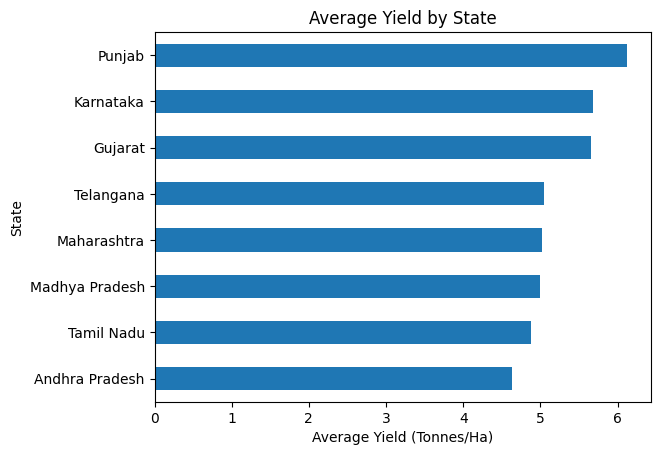

In [95]:
# STATE-WISE YIELD ANALYSIS

state_yield = df.groupby(
    "State"
)["Yield_Tonnes_Ha"].mean().sort_values(
    ascending=False
)

print("Average yield by state:")
print(state_yield)

state_yield.sort_values().plot(kind="barh")

plt.title("Average Yield by State")
plt.xlabel("Average Yield (Tonnes/Ha)")
plt.ylabel("State")
plt.show()

In [97]:
# KEY FINDINGS / MEANINGFUL INSIGHTS

best_yield_season = season_yield.idxmax()
best_yield_value = season_yield.max()

best_profit_season = df.groupby(
    "Season"
)["Profit_INR"].mean().idxmax()

best_profit_value = df.groupby(
    "Season"
)["Profit_INR"].mean().max()

best_crop = df.groupby(
    "Crop"
)["Yield_Tonnes_Ha"].mean().idxmax()

best_crop_yield = df.groupby(
    "Crop"
)["Yield_Tonnes_Ha"].mean().max()

best_irrigation = irrigation_yield.idxmax()
best_irrigation_yield = irrigation_yield.max()

highest_risk_season = season_risk.idxmax()
highest_risk_value = season_risk.max()

best_state_yield = state_yield.idxmax()
best_state_yield_value = state_yield.max()

best_state_profit = state_profit.idxmax()
best_state_profit_value = state_profit.max()

print("KEY FINDINGS")
print("=" * 60)

print(f"1. {best_yield_season} has the highest average yield "
      f"at {best_yield_value:.2f} tonnes/ha.")

print(f"2. {best_profit_season} has the highest average profit "
      f"at ₹{best_profit_value:,.2f}.")

print(f"3. {best_crop} has the highest average yield "
      f"at {best_crop_yield:.2f} tonnes/ha.")

print(f"4. {best_irrigation} irrigation has the highest average yield "
      f"at {best_irrigation_yield:.2f} tonnes/ha.")

print(f"5. {highest_risk_season} has the highest average disease/pest risk "
      f"at {highest_risk_value:.2f}%.")

print(f"6. {best_state_yield} has the highest average yield among states "
      f"at {best_state_yield_value:.2f} tonnes/ha.")

print(f"7. {best_state_profit} has the highest average profit among states "
      f"at ₹{best_state_profit_value:,.2f}.")

print(f"8. Rainfall and yield have a correlation of "
      f"{rainfall_yield_corr:.3f}, indicating a weak linear relationship.")

print(f"9. Fertilizer and yield have a correlation of "
      f"{fertilizer_yield_corr:.3f}.")



KEY FINDINGS
1. Kharif has the highest average yield at 5.63 tonnes/ha.
2. Kharif has the highest average profit at ₹178,914.65.
3. Sugarcane has the highest average yield at 46.64 tonnes/ha.
4. Drip irrigation has the highest average yield at 6.58 tonnes/ha.
5. Kharif has the highest average disease/pest risk at 54.47%.
6. Punjab has the highest average yield among states at 6.12 tonnes/ha.
7. Punjab has the highest average profit among states at ₹136,025.64.
8. Rainfall and yield have a correlation of 0.031, indicating a weak linear relationship.
9. Fertilizer and yield have a correlation of 0.000.


## Evidence-Based Recommendations

Based on the analysis performed on the agricultural dataset, the following recommendations can be considered:

1. Seasonal performance should be monitored using yield, profit, water usage and environmental indicators together rather than using yield alone.

2. Irrigation methods should be evaluated based on both crop yield and water efficiency to support better resource management.

3. The seasonal differences in disease and pest risk should be monitored, especially during periods showing higher observed risk.

4. Crop-wise and state-wise performance should be compared before making agricultural planning decisions.

5. Farmers and planners should consider environmental variables such as rainfall, temperature, humidity and soil moisture when evaluating seasonal performance.

6. Resource usage such as fertilizer, pesticide and water should be monitored alongside yield and profitability.

7. Unusually high or low yield and profit observations should be investigated further rather than automatically removed from the dataset.

8. Since the ANOVA result does not show a statistically significant difference in yield between seasons at the 5% level, seasonal planning decisions should consider additional factors and more historical data.

## Limitations

1. The analysis is based on the available dataset and may not represent all agricultural regions or farming conditions.

2. The dataset contains records from a limited number of states, districts and crops.

3. The analysis is observational, so relationships between variables should not be interpreted as proof of cause and effect.

4. Median imputation was used for missing rainfall, soil moisture and yield values, which may slightly affect some statistical results.

5. Outliers were identified for investigation but were not automatically removed because they may represent genuine agricultural conditions.

6. More historical and multi-year data would be required to study long-term seasonal trends.

7. Market prices, costs and profits may vary over time and across locations.

8. The analysis does not include every possible agricultural factor, such as detailed weather forecasts, farm machinery, labour availability or changing market conditions.

##  Conclusion

The Seasonal Agriculture Performance Analysis examined agricultural records across different seasons, crops, states, environmental conditions, resource usage and economic outcomes.

The analysis identified differences in average yield, profit, water usage and disease/pest risk across seasons. Kharif showed the highest average yield and average profit in the dataset, while crop and irrigation comparisons showed noticeable differences in performance.

The analysis also examined relationships between environmental and resource variables and crop yield. Correlation analysis showed that some relationships were weak, indicating that yield performance cannot be explained by a single factor.

Outlier analysis helped identify unusual yield, profit and water usage observations, while multivariate analysis provided comparisons across crops, states and seasons.

The ANOVA test did not show a statistically significant difference in yield between seasons at the 5% significance level. Therefore, the results should be interpreted as observed patterns in the dataset rather than definitive causal relationships.

Overall, the project demonstrates how data analysis, visualization and statistical techniques can be used to understand agricultural performance and support evidence-based planning.

# Project Submission Checklist

- Dataset loaded successfully
- Top 5 rows analyzed
- Dataset shape and structure examined
- Data types examined
- Missing values identified and handled
- Duplicate records identified and handled
- Descriptive/statistical analysis performed
- Outliers investigated
- Univariate analysis completed
- Bivariate analysis completed
- Multivariate analysis completed
- Correlation analysis completed
- Seasonal comparisons performed
- At least 3 student-designed analyses completed
- At least 8 meaningful insights documented
- Evidence-based recommendations provided
- Limitations discussed
- Final conclusion provided